HYPERPARAMETER TUNING

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import make_scorer, precision_recall_curve

print("--- STARTING GPU-POWERED HYPERPARAMETER TUNING ---")

# ==========================================
# 1. Define the Custom F2-Max Scorer
# ==========================================
def max_f2_scorer(y_true, y_pred_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    
    # Align array lengths
    precision = precision[:-1]
    recall = recall[:-1]
    
    # Calculate F2 scores for all thresholds
    beta = 2
    f2_scores = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-10)
    
    # Return the highest F2 score achievable
    return np.max(f2_scores)

# Wrap it in make_scorer so RandomizedSearchCV can use it. 
# response_method='predict_proba' ensures it passes probabilities, not hard 0/1 predictions.
f2_dynamic_scorer = make_scorer(max_f2_scorer, response_method='predict_proba')


# ==========================================
# 2. Data Loading & Setup
# ==========================================
df_final = pd.read_parquet('../data/final/train_hospital_A_optimized.parquet')

groups = df_final['Patient_ID']
x = df_final.drop(columns=['SepsisLabel', 'Patient_ID'])
y = df_final['SepsisLabel']

imbalance_ratio = (y == 0).sum() / (y == 1).sum()
print(f"Dataset Imbalance Ratio: {imbalance_ratio:.2f}")


# ==========================================
# 3. Define the Hyperparameter Grid
# ==========================================
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}


# ==========================================
# 4. Initialize Base Model & CV
# ==========================================
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    eval_metric='aucpr',  
    tree_method='hist', 
    device='cuda',       
    random_state=42
)

gkf = GroupKFold(n_splits=3)


# ==========================================
# 5. Execute the F2-Optimized Search
# ==========================================
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,
    scoring=f2_dynamic_scorer,
    cv=gkf,              
    verbose=2,
    random_state=42
)

print("Searching for the optimal hyperparameters to maximize F2 Score...")
random_search.fit(x, y, groups=groups)


# ==========================================
# 6. Results
# ==========================================
print("\n--- TUNING COMPLETE ---")
print("Best Hyperparameters Found:")
for key, value in random_search.best_params_.items():
    print(f"  {key}: {value}")

print(f"\nBest Cross-Validated Max F2-Score: {random_search.best_score_:.4f}")

--- STARTING GPU-POWERED HYPERPARAMETER TUNING ---
Dataset Imbalance Ratio: 71.98
Searching for the optimal hyperparameters to maximize F2 Score...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.6, learning_rate=0.02, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.6; total time=   4.3s
[CV] END colsample_bytree=0.6, learning_rate=0.02, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.6; total time=   3.1s
[CV] END colsample_bytree=0.6, learning_rate=0.02, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.6; total time=   3.2s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=100, subsample=1.0; total time=   3.3s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=100, subsample=1.0; total time=   3.4s
[CV] END colsample_bytree=0.6, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=100, subsample=1

TRAINIG FINAL MODEL

--- TRAINING FINAL TUNED MODEL ---
Training model (monitoring logloss for overfitting)...
Generating learning curves...


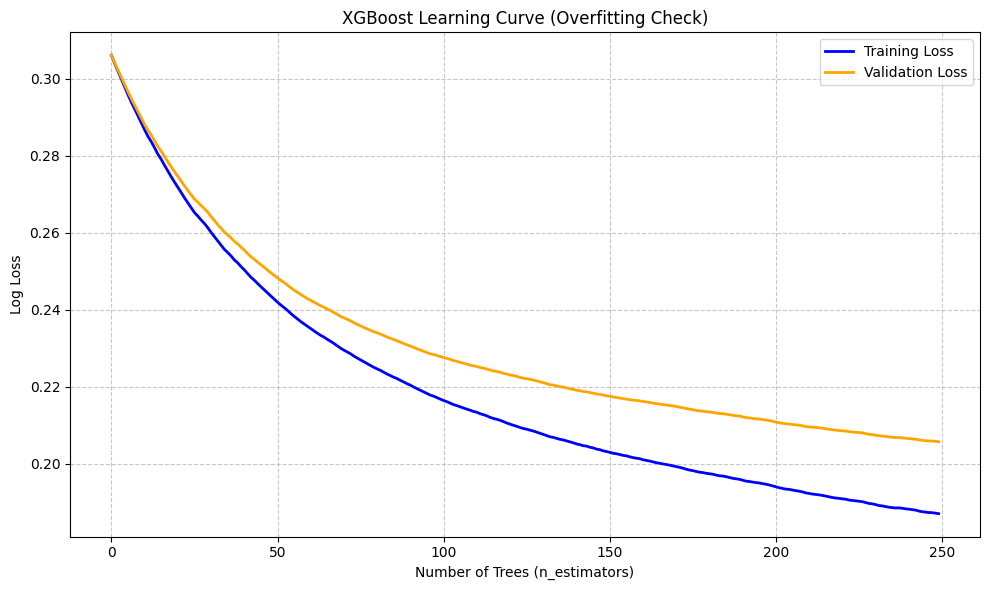

Evaluating predictions...

--- FINAL TUNED RESULTS ---
Optimal Probability Threshold: 0.3001 (30.0%)
Max F2-Score: 0.1986
Precision:    0.0582 (When the alarm sounds, it is correct 5.8% of the time)
Recall:       0.5000 (The alarm catches 50.0% of all actual Sepsis cases)


In [67]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_recall_curve

print("--- TRAINING FINAL TUNED MODEL ---")

# 1. Load Data
df_final = pd.read_parquet('../data/final/train_hospital_A_optimized.parquet')

groups = df_final['Patient_ID']
x = df_final.drop(columns=['SepsisLabel', 'Patient_ID'])
y = df_final['SepsisLabel']

# 2. GroupShuffleSplit (Preventing Data Leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(x, y, groups))

x_train, x_val = x.iloc[train_idx], x.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

# 3. Calculate Imbalance Ratio for the training set
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 4. Train with Tuned Hyperparameters
print("Training model (monitoring logloss for overfitting)...")
clf_final = xgb.XGBClassifier(
    max_depth=6,                 
    min_child_weight=1,          
    learning_rate=0.02,          
    n_estimators=250,            
    subsample=0.5,               
    colsample_bytree=0.8,        
    scale_pos_weight=imbalance_ratio * 0.3, 
    eval_metric=['logloss', 'aucpr'], 
    tree_method='hist',
    device='cuda',               
    random_state=42
)

# Added eval_set to track performance per tree
clf_final.fit(
    x_train, y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=False 
)

# ==========================================
# PLOTTING THE LEARNING CURVES
# ==========================================
print("Generating learning curves...")
results = clf_final.evals_result()

# validation_0 is the training set, validation_1 is the validation set
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']
epochs = len(train_loss)
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(x_axis, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.legend()
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Log Loss')
plt.title('XGBoost Learning Curve (Overfitting Check)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# ==========================================

# 5. Evaluate Optimal Threshold
print("Evaluating predictions...")
y_pred_proba = clf_final.predict_proba(x_val)[:, 1]
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_pred_proba)

precision = precision[:-1]
recall = recall[:-1]

beta = 2
f2_scores = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-10)

best_idx = np.argmax(f2_scores)

print("\n--- FINAL TUNED RESULTS ---")
print(f"Optimal Probability Threshold: {pr_thresholds[best_idx]:.4f} ({pr_thresholds[best_idx]*100:.1f}%)")
print(f"Max F2-Score: {f2_scores[best_idx]:.4f}")
print(f"Precision:    {precision[best_idx]:.4f} (When the alarm sounds, it is correct {precision[best_idx]*100:.1f}% of the time)")
print(f"Recall:       {recall[best_idx]:.4f} (The alarm catches {recall[best_idx]*100:.1f}% of all actual Sepsis cases)")

Saving final tuned model

In [69]:
# Save the XGBoost model 
model_path = '../models/tuned_model.json'
clf_final.save_model(model_path)
print(f"Tuned Model saved to: {model_path}")

Tuned Model saved to: ../models/tuned_model.json


Confusion Matrix

--- GENERATING CONFUSION MATRIX ---


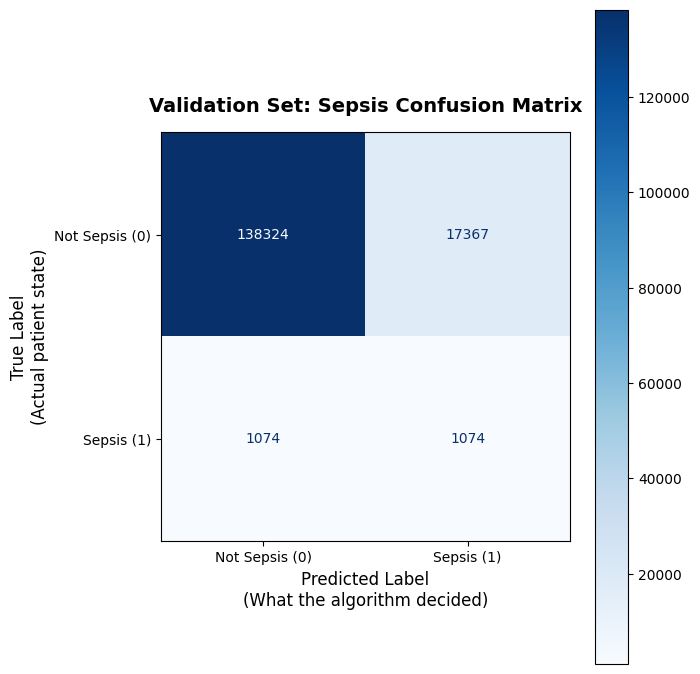

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("--- GENERATING CONFUSION MATRIX ---")

# Use the same optimal threshold selected from the PR/F2 analysis
optimal_threshold = pr_thresholds[best_idx]
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

# 1. Calculate the raw confusion matrix
cm = confusion_matrix(y_val, y_pred_binary)

# 2. Set up the display object with clear clinical labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Not Sepsis (0)', 'Sepsis (1)']
)

# 3. Plot the matrix
fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(cmap='Blues', ax=ax, values_format='d') 

# 4. Add clinical context to the axes
plt.title('Validation Set: Sepsis Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label\n(What the algorithm decided)', fontsize=12)
plt.ylabel('True Label\n(Actual patient state)', fontsize=12)

plt.tight_layout()
plt.show()